<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
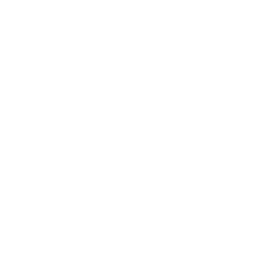
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Electoral Precinct Voting Pattern Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Government / Election Statistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 핵심 요약

이 분석은 100개 선거구로 구성된 모의 카운티 선거 데이터셋에서 선거구 유형(도시, 교외,
농촌)에 따라 정당 지지가 체계적으로 달라지는지를 살펴봅니다. 정당×유형 분할표의 여러
셀이 희박하여 — 가장 작은 셀은 선거구 1~2개만 포함하고, 기대도수가 5 미만인 경우가
많습니다 — 일반 연관성에 대한 포괄적인 피어슨 카이제곱 검정은 검정력이 부족하고
신뢰하기 어렵습니다. 따라서 이를 **코크란-아미티지 경향성 검정(Cochran-Armitage trend
test)**으로 보완합니다. 이는 도시에서 농촌으로 이어지는 자연스러운 순서를 활용하는,
초점이 명확한 단일 자유도 검정으로, "정당A의 지지율이 그 기울기를 따라 단조적으로
감소하는가"라는 더 예리한 질문을 던집니다. 경향성 검정은 정확 p-값을 보고하는데, 이는
셀 개수가 작을 때 적절한 추론 방법입니다. 두 검정의 대비가 이 예제의 분석적 핵심입니다:
일반적인 연관성 검정은 순서화된 경향성 검정이 탐지하는 실제 방향성 패턴을 놓칠 수
있습니다.


## 데이터 원본

| 원본 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | 선거구 단위 레코드, 선거구별 1행, 선거구 유형·카운티·최다 득표 정당 포함 | 100 |

이 실행 환경은 비라이선스 모드로 동작하여 출력이 100개 관측값으로 제한됩니다. 이
분석은 분할표 셀이 실제로 작아 정확 경향성 검정이 자연스러운 도구가 되도록, 이
선거구 단위 표본에 맞추어 설계되었습니다.


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic precinct-level voting data
   Small cell counts in rural precincts to demonstrate
   need for exact tests
   -------------------------------------------------------- */
데이터 work.precinct_votes;
    호출 streaminit(42);
    길이 county_name $30 precinct_type $10 party $12;
    반복 precinct_seq = 1 까지 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        만약 county_idx = 1 이면 county_name = '제퍼슨군';
        아니면 만약 county_idx = 2 이면 county_name = '해밀턴군';
        아니면 만약 county_idx = 3 이면 county_name = '매디슨군';
        아니면 만약 county_idx = 4 이면 county_name = '애덤스군';
        아니면 county_name = '먼로군';
        /* Assign precinct type with weighting */
        type_prob = rand('uniform');
        만약 type_prob < 0.30 이면 precinct_type = '도시';
        아니면 만약 type_prob < 0.65 이면 precinct_type = '교외';
        아니면 precinct_type = '농촌';
        /* Assign party with type-dependent distribution */
        party_prob = rand('uniform');
        만약 precinct_type = '도시' 이면 반복;
            만약 party_prob < 0.55 이면 party = '정당A';
            아니면 만약 party_prob < 0.80 이면 party = '정당B';
            아니면 만약 party_prob < 0.92 이면 party = '정당C';
            아니면 party = '무소속';
        종료;
        아니면 만약 precinct_type = '교외' 이면 반복;
            만약 party_prob < 0.40 이면 party = '정당A';
            아니면 만약 party_prob < 0.75 이면 party = '정당B';
            아니면 만약 party_prob < 0.88 이면 party = '정당C';
            아니면 party = '무소속';
        종료;
        아니면 반복; /* 농촌 - smaller cells for minority parties */
            만약 party_prob < 0.25 이면 party = '정당A';
            아니면 만약 party_prob < 0.70 이면 party = '정당B';
            아니면 만약 party_prob < 0.85 이면 party = '정당C';
            아니면 party = '무소속';
        종료;
        /* Vote count varies by precinct type */
        만약 precinct_type = '도시' 이면
            vote_count = int(rand('normal', 120, 40));
        아니면 만약 precinct_type = '교외' 이면
            vote_count = int(rand('normal', 80, 25));
        아니면
            vote_count = int(rand('normal', 25, 12));
        만약 vote_count < 1 이면 vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        출력;
    종료;
    제거 precinct_seq county_idx type_prob party_prob;
    라벨 county_name='선거구가 속한 군' precinct_type='선거구 유형' party='정당'
          vote_count='득표수' registered_voters='등록 유권자 수' turnout_pct='투표율(%)';
실행;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

선거구 유형              Frequency    Percent
-----------------------------------------
교외                         37     37.00
농촌                         34     34.00
도시                         29     29.00

정당           Frequency    Percent
----------------------------------
무소속                  9      9.00
정당A                 45     45.00
정당B                 34     34.00
정당C                 12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


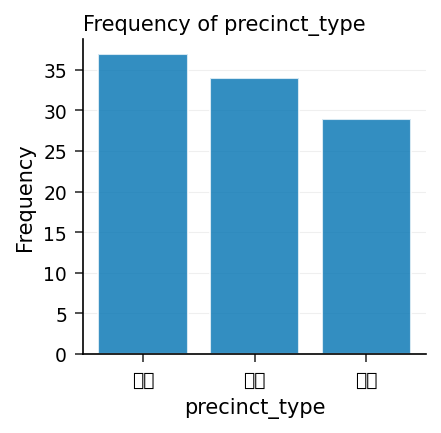

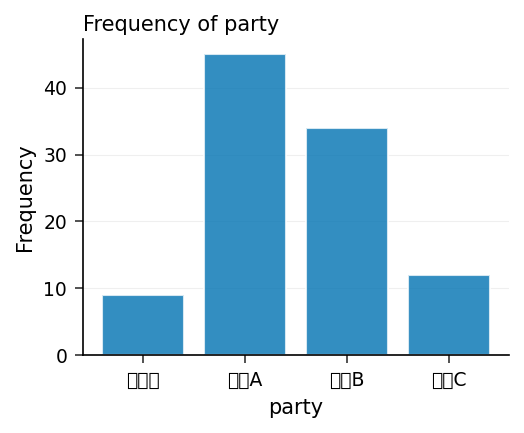

In [2]:
/* --------------------------------------------------------
   Baseline precinct type and party distribution
   -------------------------------------------------------- */
처리 빈도 데이터=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    라벨 precinct_type='선거구 유형' party='정당';
실행;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


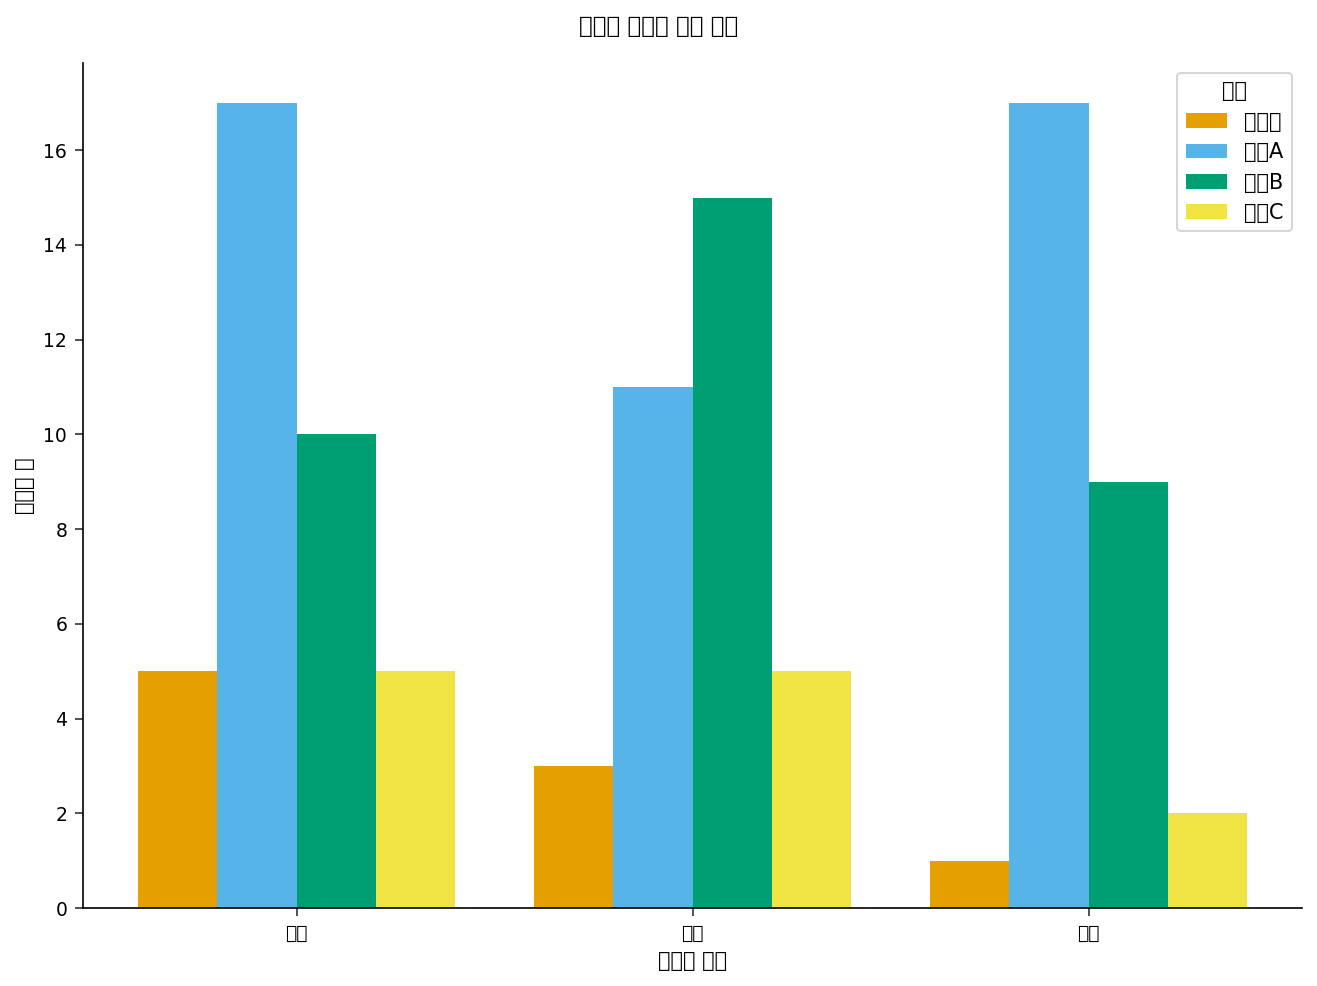

In [3]:
/* --------------------------------------------------------
   Party affiliation by precinct type (precinct counts)
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=빈도;
    XAXIS 라벨='선거구 유형';
    YAXIS 라벨='선거구 수';
    keylegend / 제목='정당';
    제목 '선거구 유형별 정당 지지';
실행;


---

                                               선거구 유형과 정당의 교차표 (기대도수 포함)                                                

                                                   The FREQ Procedure

Table of 선거구 유형 by 정당

선거구 유형           |       무소속 |       정당A |       정당B |       정당C |      Total
-----------------+-----------+-----------+-----------+-----------+-----------
교외               |         5 |        17 |        10 |         5 |         37
                 |      5.00 |     17.00 |     10.00 |      5.00 |      37.00
                 |      3.33 |     16.65 |     12.58 |      4.44 |           
                 |     13.51 |     45.95 |     27.03 |     13.51 |     100.00
                 |     55.56 |     37.78 |     29.41 |     41.67 |      37.00
-----------------+-----------+-----------+-----------+-----------+-----------
농촌               |         3 |        11 |        15 |         5 |         34
                 |      3.00 |     11.00 |     15.00 |      5.00 |      34.00
    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


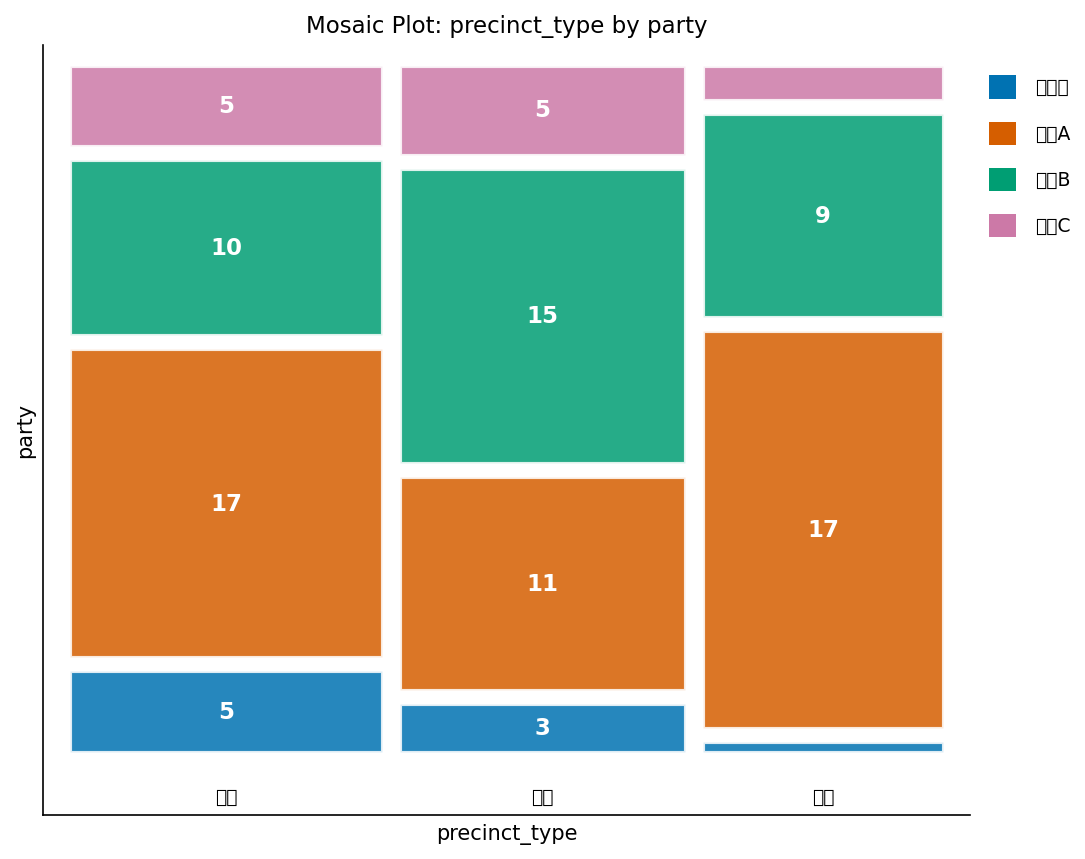

In [4]:
/* --------------------------------------------------------
   Precinct type x party cross-tabulation.
   Request EXPECTED counts so the sparse cells are visible,
   plus the asymptotic Pearson chi-square test of general
   association. Note the small expected counts in the
   INDEPENDENT and PARTY_C columns -- the cue that an
   ordered, exact trend test is the better inferential tool.
   -------------------------------------------------------- */
처리 빈도 데이터=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    라벨 precinct_type='선거구 유형' party='정당';
    제목 '선거구 유형과 정당의 교차표 (기대도수 포함)';
실행;


                                           코크란-아미티지 경향성 검정: 선거구 등급에 따른 정당A 지지                                           

                                                   The FREQ Procedure

Table of 선거구 순서 (1=도시,2=교외,3=농촌) by 정당A 지지 여부

선거구 순서 (1=도시,2=교외,3=농촌)                       |         0 |         1 |      Total
----------------------------------------------+-----------+-----------+-----------
1                                             |        12 |        17 |         29
                                              |     12.00 |     17.00 |      29.00
                                              |     41.38 |     58.62 |     100.00
                                              |     21.82 |     37.78 |      29.00
----------------------------------------------+-----------+-----------+-----------
2                                             |        20 |        17 |         37
                                              |     20.00 |     17.00 |      37.00
             


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


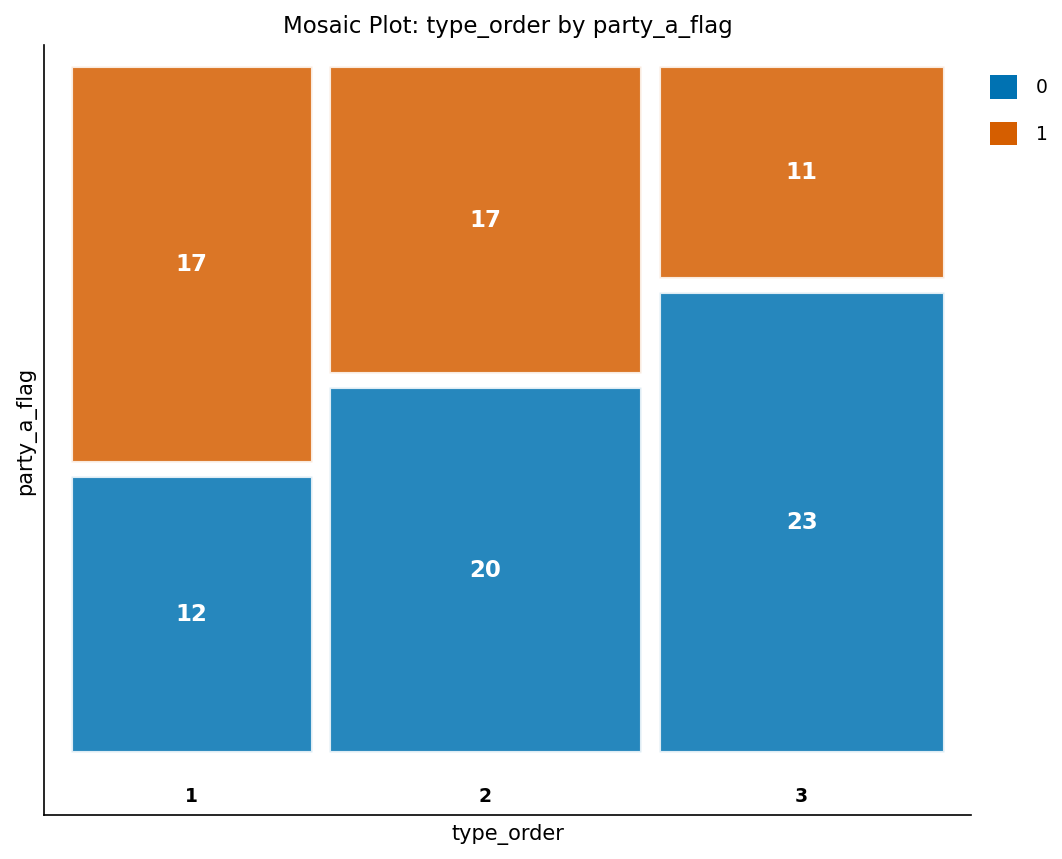

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage trend test. Recode precinct type to an
   ordinal score (1=Urban, 2=Suburban, 3=Rural) and test
   whether Party A support shows a monotonic trend across
   the gradient. EXACT TREND requests the exact p-value,
   appropriate given the small cell counts.
   -------------------------------------------------------- */
데이터 work.precinct_ordinal;
    설정 work.precinct_votes;
    /* Ordinal coding: 1=Urban, 2=Suburban, 3=Rural */
    만약 precinct_type = '도시' 이면 type_order = 1;
    아니면 만약 precinct_type = '교외' 이면 type_order = 2;
    아니면 type_order = 3;
    /* Binary outcome: Party A vs. all other affiliations */
    party_a_flag = (party = '정당A');
    라벨 type_order='선거구 순서 (1=도시,2=교외,3=농촌)' party_a_flag='정당A 지지 여부';
실행;

처리 빈도 데이터=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    라벨 type_order='선거구 순서 (1=도시,2=교외,3=농촌)' party_a_flag='정당A 지지 여부';
    제목 '코크란-아미티지 경향성 검정: 선거구 등급에 따른 정당A 지지';
실행;


                                                      군별 선거구 유형 분포                                                      

                                                   The FREQ Procedure

Table of 선거구가 속한 군 by 선거구 유형

선거구가 속한 군               |        교외 |        농촌 |        도시 |      Total
------------------------+-----------+-----------+-----------+-----------
매디슨군                    |         1 |        13 |         9 |         23
                        |      1.00 |     13.00 |      9.00 |      23.00
                        |      4.35 |     56.52 |     39.13 |     100.00
                        |      2.70 |     38.24 |     31.03 |      23.00
------------------------+-----------+-----------+-----------+-----------
먼로군                     |        12 |         5 |         2 |         19
                        |     12.00 |      5.00 |      2.00 |      19.00
                        |     63.16 |     26.32 |     10.53 |     100.00
                        |     32.43 |     14.71


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


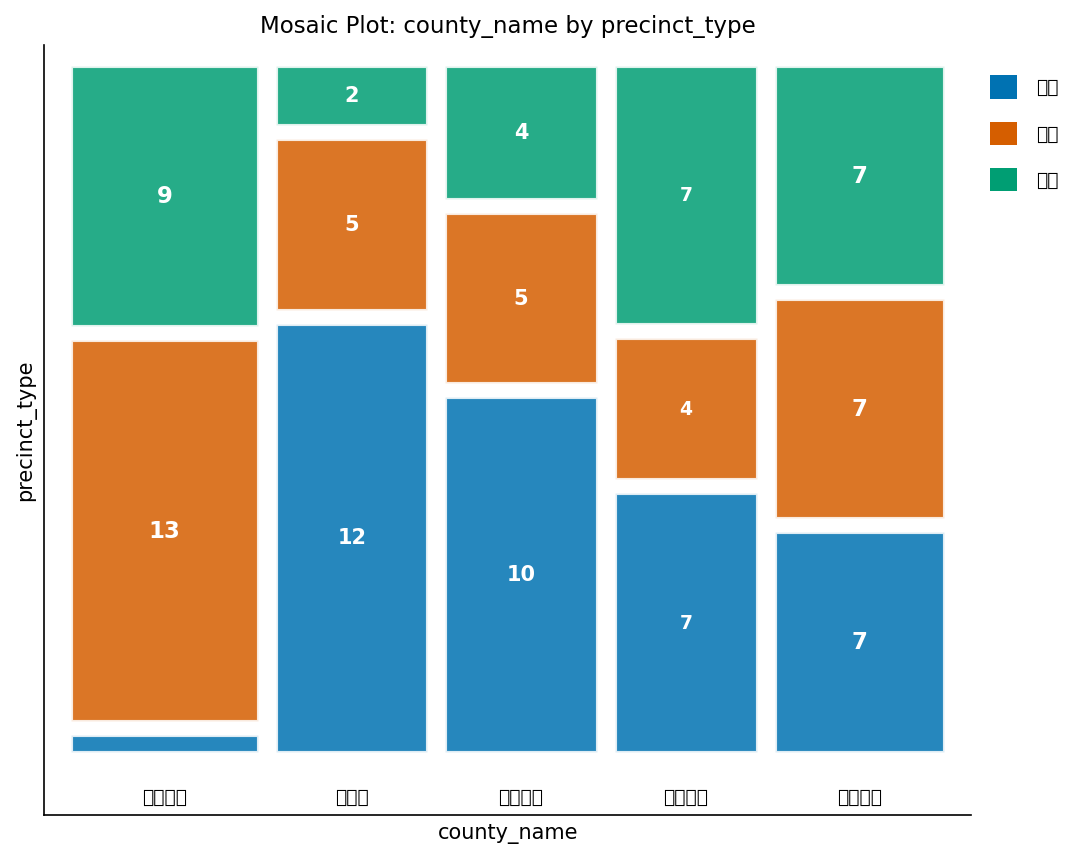

In [6]:
/* --------------------------------------------------------
   County-level view: how the urban/suburban/rural mix
   varies across the five counties. This contextualizes the
   trend result -- the precinct gradient is present in every
   county, but its composition differs.
   -------------------------------------------------------- */
처리 빈도 데이터=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    라벨 county_name='선거구가 속한 군' precinct_type='선거구 유형';
    제목 '군별 선거구 유형 분포';
실행;


---

### 결과 해석

100개 선거구 전체에서 정당A가 전반적으로 다수를 차지하며(45개 선거구), 정당B(34),
정당C(12), 무소속(9)이 뒤를 잇습니다. 교차표를 보면 정당A의 지지율은 도시에서
농촌으로 이어지는 뚜렷한 기울기를 따릅니다: 도시 선거구의 58.6%, 교외 선거구의
46.0%, 농촌 선거구의 32.4%를 차지하는 반면, 정당B는 반대 방향으로 움직여 도시
31.0%에서 농촌 44.1%로 상승합니다.

일반 연관성에 대한 포괄적인 피어슨 카이제곱 검정은 통계적으로 유의하지
**않습니다**(카이제곱 = 6.78, 자유도 6, p = 0.3418; 크래머의 V = 0.18). 이 결과 또한
취약합니다: 기대도수 표를 보면 5 미만인 셀이 여러 개 나타나는데 — 예를 들어 무소속
열의 기대도수는 각각 3.06, 3.33, 2.61이며 도시 지역의 무소속은 단 1개 선거구뿐입니다
— 따라서 대표본 카이제곱 근사가 여기서는 신뢰할 수 없습니다.

코크란-아미티지 경향성 검정은 도시-교외-농촌의 순서형 점수화를 이용해 질문을
날카롭게 다듬습니다. 이 검정은 포괄적 검정이 놓치는 정당A 지지율의 단조 감소를
탐지합니다: 경향성 카이제곱 = 4.38, 점근적 Pr > ChiSq = 0.0363, **정확 Pr >= |Z| =
0.0431**로 0.05 수준에서 유의합니다. 이것이 이 분석의 핵심 성과입니다 — 희박한
셀 때문에 약화된 일반적인 자유도 6의 연관성 검정으로는 탐지하지 못하는 실제
방향성 신호를, 초점이 명확한 정확 단일 자유도 검정이 회복해 냅니다.

카운티 단위 시각에서는 도시/교외/농촌 구성 비율이 5개 카운티 모두에 존재하지만
그 구성은 카운티마다 다르다는 것이 확인됩니다: 매디슨군이 가장 농촌 비중이
높고(23개 선거구 중 13개가 농촌) 먼로군이 가장 교외 비중이 높습니다(19개 선거구
중 12개). 선거구 재조정 영향 평가를 위해서는, 선거구를 도시-농촌 축을 따라
이동시키는 경계 변경이 정당 구성을 측정 가능한 수준으로 바꿀 것이며, 이러한
지리적 경향은 포괄적 카이제곱 검정보다 정확 경향성 검정으로 가장 잘 입증된다는
점이 핵심 시사점입니다.


---

                                                      군별 선거구 유형 분포                                                      

                                                   The FREQ Procedure

Table of 선거구 유형 by 정당

선거구 유형           |       무소속 |       정당A |       정당B |       정당C |      Total
-----------------+-----------+-----------+-----------+-----------+-----------
교외               |         5 |        17 |        10 |         5 |         37
                 |      5.00 |     17.00 |     10.00 |      5.00 |      37.00
                 |     13.51 |     45.95 |     27.03 |     13.51 |     100.00
                 |     55.56 |     37.78 |     29.41 |     41.67 |      37.00
-----------------+-----------+-----------+-----------+-----------+-----------
농촌               |         3 |        11 |        15 |         5 |         34
                 |      3.00 |     11.00 |     15.00 |      5.00 |      34.00
                 |      8.82 |     32.35 |     44.12 |     14.71 |     100.00
    


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


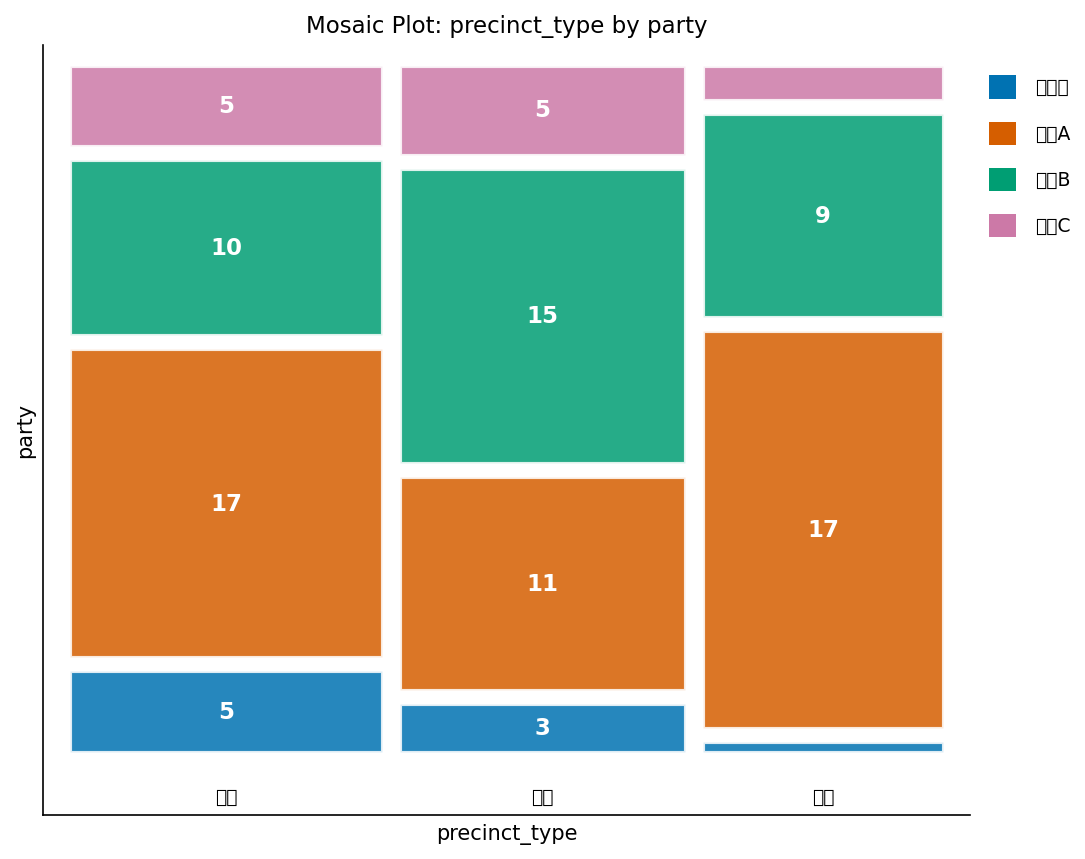

In [7]:
/* --------------------------------------------------------
   Export the precinct type x party summary for downstream
   redistricting impact assessment.
   -------------------------------------------------------- */
처리 빈도 데이터=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
실행;

처리 EXPORT 데이터=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
실행;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner 제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>